
# India VIX → Next-Day NIFTY 50 Gap Direction Classifier

### Objective
Build a three-class machine-learning model that predicts whether the **NIFTY 50 will gap UP, gap DOWN, or remain FLAT at the next day's open**, using only information available from **India VIX** at the current day's close.

### Data split
- **Last 6 months:** downloaded automatically relative to the date the notebook is run.
- **First 4 months:** training set.
- **Last 2 months:** completely out-of-sample test set.
- The split is chronological — **no random train/test split** is used.

### Target definition
For trading day *t*:

`Next_Day_Gap_% = (NIFTY_Open[t+1] / NIFTY_Close[t] - 1) × 100`

The default classification threshold is **±0.15%**:
- `GAP_UP`: next-day gap > +0.15%
- `FLAT`: -0.15% ≤ next-day gap ≤ +0.15%
- `GAP_DOWN`: next-day gap < -0.15%

You can change this threshold in the configuration cell.


In [1]:

# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

# If your environment already has these packages, you can comment
# out the pip-install line.

%pip install -q --upgrade yfinance scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("Libraries imported successfully.")


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [2]:

# ============================================================
# 2. CONFIGURATION
# ============================================================

# Change this if you want a different definition of "FLAT".
FLAT_THRESHOLD_PCT = 0.15

# Random seed for reproducibility.
RANDOM_STATE = 42

# Model parameters.
MODEL_PARAMS = {
    "max_iter": 250,
    "learning_rate": 0.05,
    "max_leaf_nodes": 15,
    "l2_regularization": 1.0,
    "random_state": RANDOM_STATE
}

print(f"Flat threshold: ±{FLAT_THRESHOLD_PCT:.2f}%")


Flat threshold: ±0.15%



## 3. Download the last six months of India VIX and NIFTY 50 data

Yahoo Finance provides the India VIX symbol `^INDIAVIX` and NIFTY 50 symbol `^NSEI`.

For production research, it is worth cross-checking the downloaded series against NSE historical data because NSE is the primary exchange source. NSE provides historical India VIX and NIFTY index data directly. citeturn0search0turn0search2


In [3]:

# ============================================================
# 3. DOWNLOAD LAST 6 MONTHS OF DATA
# ============================================================

from dateutil.relativedelta import relativedelta
from datetime import datetime

today = pd.Timestamp.today().normalize()

# Six-month window.
start_date = today - relativedelta(months=6)
end_date = today + pd.Timedelta(days=1)  # Include today's data if available.

print("Download window:")
print("Start:", start_date.date())
print("End:  ", today.date())

# Download India VIX.
vix = yf.download(
    "^INDIAVIX",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

# Download NIFTY 50.
nifty = yf.download(
    "^NSEI",
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

if vix.empty:
    raise ValueError(
        "India VIX download returned no data. "
        "Check your internet connection or Yahoo Finance availability."
    )

if nifty.empty:
    raise ValueError(
        "NIFTY 50 download returned no data. "
        "Check your internet connection or Yahoo Finance availability."
    )

print(f"India VIX rows downloaded: {len(vix)}")
print(f"NIFTY 50 rows downloaded: {len(nifty)}")


Download window:
Start: 2026-04-03
End:   2026-10-03
India VIX rows downloaded: 124
NIFTY 50 rows downloaded: 124


In [4]:

# ============================================================
# 4. CLEAN YFINANCE COLUMN FORMAT
# ============================================================

def clean_yfinance_columns(df):
    """Flatten yfinance MultiIndex columns when necessary."""
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        # Usually the first level contains OHLCV names.
        df.columns = df.columns.get_level_values(0)

    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df.sort_index()

    # Keep the standard columns if they exist.
    required = ["Open", "High", "Low", "Close"]
    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return df[required + ([c for c in ["Volume"] if c in df.columns])]

vix = clean_yfinance_columns(vix)
nifty = clean_yfinance_columns(nifty)

print("VIX:")
display(vix.tail())

print("\nNIFTY:")
display(nifty.tail())


VIX:


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-25,12.69,12.84,11.77,12.16,0
2026-09-28,12.16,14.15,12.16,13.64,0
2026-09-29,13.64,14.77,13.21,13.41,0
2026-09-30,13.41,13.86,12.77,13.49,0
2026-10-01,13.49,15.69,13.49,14.46,0



NIFTY:


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-25,23035.000000,23162.699219,23020.949219,23140.500000,242700
2026-09-28,23064.900391,23080.250000,22762.199219,22780.250000,261500
2026-09-29,22732.449219,22753.250000,22569.650391,22716.199219,603200
2026-09-30,22665.000000,22809.349609,22595.199219,22620.449219,379000
2026-10-01,22543.699219,22610.599609,22217.300781,22421.949219,463600



## 5. Build the target and India VIX features

The model uses only **current-day and historical India VIX information**. It does **not** use the next day's NIFTY open as a feature.

That separation is important: the next day's NIFTY open is used only to create the target, so there is no direct look-ahead leakage.


In [5]:

# ============================================================
# 5. CREATE FEATURES + TARGET
# ============================================================

# Keep only dates where both markets have observations.
df = vix.join(
    nifty[["Open", "Close"]].rename(
        columns={"Open": "NIFTY_Open", "Close": "NIFTY_Close"}
    ),
    how="inner"
)

# Rename VIX columns for clarity.
df = df.rename(columns={
    "Open": "VIX_Open",
    "High": "VIX_High",
    "Low": "VIX_Low",
    "Close": "VIX_Close"
})

# ------------------------------------------------------------
# Target: next day's NIFTY opening gap relative to today's close
# ------------------------------------------------------------
df["Next_NIFTY_Open"] = df["NIFTY_Open"].shift(-1)

df["Gap_Pct"] = (
    (df["Next_NIFTY_Open"] / df["NIFTY_Close"]) - 1
) * 100

# ------------------------------------------------------------
# Three-class target
# ------------------------------------------------------------
df["Target"] = np.select(
    [
        df["Gap_Pct"] > FLAT_THRESHOLD_PCT,
        df["Gap_Pct"] < -FLAT_THRESHOLD_PCT
    ],
    [
        "GAP_UP",
        "GAP_DOWN"
    ],
    default="FLAT"
)

# ------------------------------------------------------------
# India VIX features
# ------------------------------------------------------------

# 1-day percentage change
df["VIX_Return_1D"] = df["VIX_Close"].pct_change() * 100

# Intraday range
df["VIX_Range_Pct"] = (
    (df["VIX_High"] - df["VIX_Low"]) / df["VIX_Close"]
) * 100

# Position of close within today's VIX range
df["VIX_Close_Position"] = (
    (df["VIX_Close"] - df["VIX_Low"]) /
    (df["VIX_High"] - df["VIX_Low"]).replace(0, np.nan)
)

# Rolling changes / momentum
for window in [3, 5, 10, 20]:
    df[f"VIX_Momentum_{window}D"] = (
        df["VIX_Close"].pct_change(window) * 100
    )

# Rolling mean / volatility
for window in [5, 10, 20]:
    df[f"VIX_MA_{window}D"] = df["VIX_Close"].rolling(window).mean()
    df[f"VIX_STD_{window}D"] = df["VIX_Close"].rolling(window).std()

# Distance from 20-day moving average
df["VIX_Distance_MA20_Pct"] = (
    (df["VIX_Close"] / df["VIX_MA_20D"]) - 1
) * 100

# VIX change acceleration
df["VIX_Return_Change"] = df["VIX_Return_1D"].diff()

print("Created dataset:")
display(df.tail())


Created dataset:


Price,VIX_Open,VIX_High,VIX_Low,VIX_Close,Volume,NIFTY_Open,NIFTY_Close,Next_NIFTY_Open,Gap_Pct,Target,...,VIX_Momentum_10D,VIX_Momentum_20D,VIX_MA_5D,VIX_STD_5D,VIX_MA_10D,VIX_STD_10D,VIX_MA_20D,VIX_STD_20D,VIX_Distance_MA20_Pct,VIX_Return_Change
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-25,12.69,12.84,11.77,12.16,0,23035.000000,23140.500000,23064.900391,-0.326698,GAP_DOWN,...,3.050844,9.846433,11.490,0.933568,12.002,0.985492,11.6550,0.817889,4.332903,-26.785202
2026-09-28,12.16,14.15,12.16,13.64,0,23064.900391,22780.250000,22732.449219,-0.209834,GAP_DOWN,...,10.984543,27.715355,11.968,1.314218,12.137,1.113484,11.8030,0.896232,15.563842,16.347572
2026-09-29,13.64,14.77,13.21,13.41,0,22732.449219,22716.199219,22665.000000,-0.225386,GAP_DOWN,...,-0.148924,19.839145,12.450,1.312383,12.135,1.110918,11.9140,0.952053,12.556654,-13.857277
2026-09-30,13.41,13.86,12.77,13.49,0,22665.000000,22620.449219,22543.699219,-0.339295,GAP_DOWN,...,2.429762,17.406441,13.078,0.630294,12.167,1.148033,12.0140,1.008534,12.285664,2.282790
2026-10-01,13.49,15.69,13.49,14.46,0,22543.699219,22421.949219,NaN,NaN,FLAT,...,17.656632,24.762725,13.432,0.824906,12.384,1.359479,12.1575,1.140567,18.938927,6.593944


In [6]:

# ============================================================
# 6. DEFINE MODEL FEATURES
# ============================================================

FEATURES = [
    "VIX_Open",
    "VIX_High",
    "VIX_Low",
    "VIX_Close",
    "VIX_Return_1D",
    "VIX_Range_Pct",
    "VIX_Close_Position",
    "VIX_Momentum_3D",
    "VIX_Momentum_5D",
    "VIX_Momentum_10D",
    "VIX_Momentum_20D",
    "VIX_MA_5D",
    "VIX_MA_10D",
    "VIX_MA_20D",
    "VIX_STD_5D",
    "VIX_STD_10D",
    "VIX_STD_20D",
    "VIX_Distance_MA20_Pct",
    "VIX_Return_Change"
]

# Remove rows where rolling features are not yet available
# or where the next day's open is unavailable.
model_df = df.dropna(subset=FEATURES + ["Gap_Pct", "Target"]).copy()

print("Rows available for modeling:", len(model_df))
print("\nTarget distribution:")
print(model_df["Target"].value_counts())


Rows available for modeling: 103

Target distribution:
Target
FLAT        36
GAP_UP      35
GAP_DOWN    32
Name: count, dtype: int64



## 7. Chronological 4-month / 2-month split

The split is based on dates, not random sampling.

This is essential for a financial forecasting problem: randomly mixing observations from the future into the training set would make the reported test performance unreliable.


In [7]:

# ============================================================
# 7. CHRONOLOGICAL SPLIT: FIRST 4 MONTHS / LAST 2 MONTHS
# ============================================================

# Model data starts slightly after the raw download date because
# rolling features require historical observations.
model_start = model_df.index.min()
model_end = model_df.index.max()

# The requested 4/2 month split is defined relative to the
# six-month modeling window.
six_month_start = start_date
four_month_cutoff = six_month_start + relativedelta(months=4)

train = model_df[
    (model_df.index >= six_month_start) &
    (model_df.index < four_month_cutoff)
].copy()

test = model_df[
    model_df.index >= four_month_cutoff
].copy()

if train.empty or test.empty:
    raise ValueError(
        "Train or test set is empty. This can happen if the data provider "
        "returned an unexpectedly short history."
    )

print("TRAINING PERIOD")
print(train.index.min().date(), "to", train.index.max().date())
print("Training observations:", len(train))

print("\nTEST PERIOD")
print(test.index.min().date(), "to", test.index.max().date())
print("Testing observations:", len(test))

print("\nTraining class distribution:")
print(train["Target"].value_counts(normalize=True).mul(100).round(2))

print("\nTesting class distribution:")
print(test["Target"].value_counts(normalize=True).mul(100).round(2))


TRAINING PERIOD
2026-05-06 to 2026-07-31
Training observations: 61

TEST PERIOD
2026-08-03 to 2026-09-30
Testing observations: 42

Training class distribution:
Target
GAP_UP      40.98
GAP_DOWN    29.51
FLAT        29.51
Name: proportion, dtype: float64

Testing class distribution:
Target
FLAT        42.86
GAP_DOWN    33.33
GAP_UP      23.81
Name: proportion, dtype: float64


In [8]:

# ============================================================
# 8. TRAIN THE CLASSIFICATION MODEL
# ============================================================

X_train = train[FEATURES]
y_train = train["Target"]

X_test = test[FEATURES]
y_test = test["Target"]

model = HistGradientBoostingClassifier(**MODEL_PARAMS)

model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [9]:

# ============================================================
# 9. TEST-SET PREDICTIONS
# ============================================================

test = test.copy()

test["Predicted_Class"] = model.predict(X_test)

# Probability of each class
probabilities = model.predict_proba(X_test)

for i, class_name in enumerate(model.classes_):
    test[f"Prob_{class_name}"] = probabilities[:, i]

print("Test predictions:")
display(
    test[
        [
            "NIFTY_Close",
            "Next_NIFTY_Open",
            "Gap_Pct",
            "Target",
            "Predicted_Class"
        ]
    ].tail(20)
)


Test predictions:


Price,NIFTY_Close,Next_NIFTY_Open,Gap_Pct,Target,Predicted_Class
Date,,,,,
2026-09-02,23914.449219,23997.949219,0.349161,GAP_UP,GAP_DOWN
2026-09-03,23873.449219,23910.900391,0.156874,GAP_UP,GAP_DOWN
2026-09-04,23897.699219,23883.150391,-0.060880,FLAT,FLAT
2026-09-07,23779.150391,23743.099609,-0.151607,GAP_DOWN,GAP_DOWN
2026-09-08,23635.099609,23522.050781,-0.478309,GAP_DOWN,GAP_DOWN
2026-09-09,23431.500000,23446.599609,0.064441,FLAT,GAP_DOWN
2026-09-10,23477.800781,23270.300781,-0.883814,GAP_DOWN,GAP_DOWN
2026-09-11,23398.099609,23576.150391,0.760963,GAP_UP,GAP_DOWN
2026-09-15,23118.599609,23201.599609,0.359018,GAP_UP,GAP_DOWN


Test Accuracy:          23.81%
Balanced Test Accuracy: 25.19%

Classification Report:
              precision    recall  f1-score   support

    GAP_DOWN       0.24      0.50      0.33        14
        FLAT       0.25      0.06      0.09        18
      GAP_UP       0.22      0.20      0.21        10

    accuracy                           0.24        42
   macro avg       0.24      0.25      0.21        42
weighted avg       0.24      0.24      0.20        42



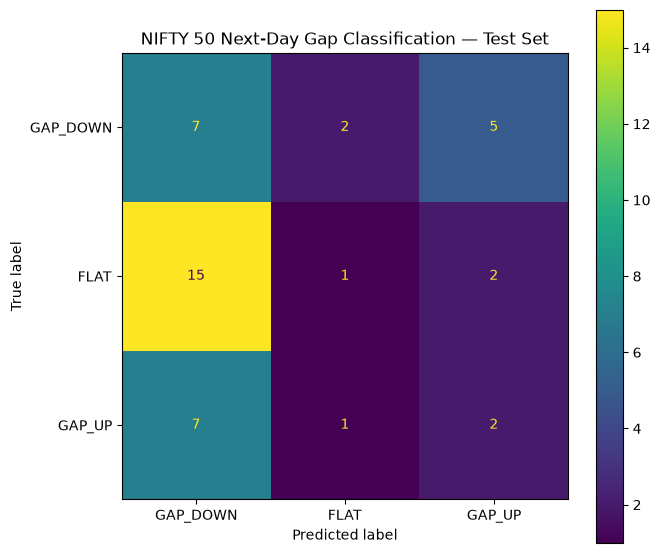

In [10]:

# ============================================================
# 10. EVALUATE MODEL
# ============================================================

accuracy = accuracy_score(y_test, test["Predicted_Class"])
balanced_acc = balanced_accuracy_score(y_test, test["Predicted_Class"])

print(f"Test Accuracy:          {accuracy:.2%}")
print(f"Balanced Test Accuracy: {balanced_acc:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test["Predicted_Class"],
        labels=["GAP_DOWN", "FLAT", "GAP_UP"],
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    test["Predicted_Class"],
    labels=["GAP_DOWN", "FLAT", "GAP_UP"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GAP_DOWN", "FLAT", "GAP_UP"]
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax)
ax.set_title("NIFTY 50 Next-Day Gap Classification — Test Set")
plt.tight_layout()
plt.show()


In [11]:

# ============================================================
# 11. COMPARE AGAINST A SIMPLE BASELINE
# ============================================================

# Baseline = always predict the most common training class.
baseline_class = y_train.value_counts().idxmax()

baseline_predictions = np.repeat(
    baseline_class,
    len(y_test)
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Most common training class:", baseline_class)
print(f"Baseline accuracy: {baseline_accuracy:.2%}")
print(f"Model accuracy:    {accuracy:.2%}")
print(f"Improvement:       {(accuracy - baseline_accuracy):.2%}")


Most common training class: GAP_UP
Baseline accuracy: 23.81%
Model accuracy:    23.81%
Improvement:       0.00%



## 12. Feature importance

Permutation importance is calculated **only on the test set**. It measures how much model performance deteriorates when each feature is randomly shuffled.

This is useful for understanding whether the model is actually relying on VIX momentum, volatility, level, etc., rather than treating the classifier as a black box.


,Feature,Importance_Mean,Importance_STD
16,VIX_STD_20D,0.000873,0.016464
3,VIX_Close,0.000000,0.000000
0,VIX_Open,0.000000,0.000000
12,VIX_MA_10D,0.000000,0.000000
13,VIX_MA_20D,0.000000,0.000000
11,VIX_MA_5D,0.000000,0.000000
4,VIX_Return_1D,0.000000,0.000000
2,VIX_Low,-0.003333,0.010000
15,VIX_STD_10D,-0.013333,0.013686
17,VIX_Distance_MA20_Pct,-0.015000,0.016583


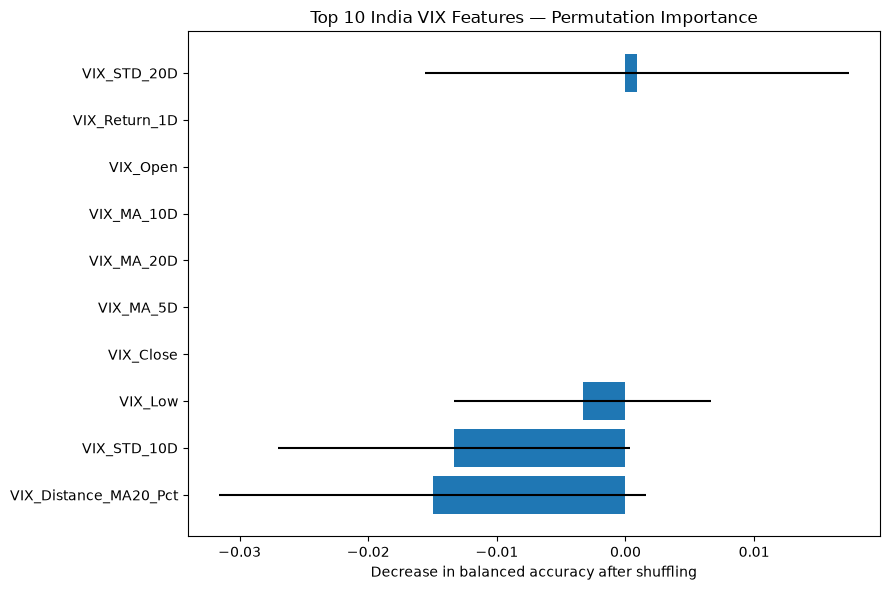

In [12]:

# ============================================================
# 12. PERMUTATION FEATURE IMPORTANCE
# ============================================================

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="balanced_accuracy"
)

importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance_Mean": perm.importances_mean,
    "Importance_STD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(importance)

# Plot top 10 features
top = importance.head(10).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top["Feature"],
    top["Importance_Mean"],
    xerr=top["Importance_STD"]
)
ax.set_title("Top 10 India VIX Features — Permutation Importance")
ax.set_xlabel("Decrease in balanced accuracy after shuffling")
plt.tight_layout()
plt.show()


In [13]:

# ============================================================
# 13. SAVE TEST PREDICTIONS
# ============================================================

output_columns = [
    "NIFTY_Close",
    "Next_NIFTY_Open",
    "Gap_Pct",
    "Target",
    "Predicted_Class"
] + [f"Prob_{c}" for c in model.classes_]

test[output_columns].to_csv(
    "nifty_gap_predictions_test.csv",
    index=True
)

# Save the full modeling dataset as well.
model_df.to_csv(
    "india_vix_nifty_gap_model_dataset.csv",
    index=True
)

print("Saved:")
print("1. nifty_gap_predictions_test.csv")
print("2. india_vix_nifty_gap_model_dataset.csv")


Saved:
1. nifty_gap_predictions_test.csv
2. india_vix_nifty_gap_model_dataset.csv


In [14]:

# ============================================================
# 14. PREDICT THE NEXT TRADING DAY
# ============================================================

# Use the most recent available VIX row.
latest = model_df.iloc[[-1]]

latest_X = latest[FEATURES]

next_prediction = model.predict(latest_X)[0]
next_probabilities = model.predict_proba(latest_X)[0]

prediction_table = pd.DataFrame({
    "Class": model.classes_,
    "Probability": next_probabilities
}).sort_values("Probability", ascending=False)

print("Latest VIX date:", latest.index[-1].date())
print("\nPredicted next-day NIFTY gap class:", next_prediction)

display(prediction_table)


Latest VIX date: 2026-09-30

Predicted next-day NIFTY gap class: FLAT


,Class,Probability
0,FLAT,0.416181
2,GAP_UP,0.356105
1,GAP_DOWN,0.227714



## 15. Important interpretation notes

### What this model is actually predicting
The model predicts the **directional class of the next NIFTY 50 opening gap**, not the entire next-day return.

For example, if today's NIFTY closes at 25,000 and tomorrow opens at 25,100:

`Gap = (25,100 / 25,000 - 1) × 100 = +0.40%`

With a ±0.15% flat threshold, this is classified as `GAP_UP`.

### Important limitation
Six months of data is a **very small sample for a financial machine-learning model**. The resulting accuracy can be unstable and should not be interpreted as evidence of a persistent trading edge.

A stronger research version should eventually use several years of data and walk-forward validation.

### Avoiding look-ahead bias
The feature set contains only India VIX information available at the current trading day's close. The next day's NIFTY open is used only to construct the target.

### India VIX context
NSE describes India VIX as a measure of expected near-term volatility derived from NIFTY option prices, with the index indicating expected volatility over approximately the next 30 calendar days. citeturn0search3
